In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

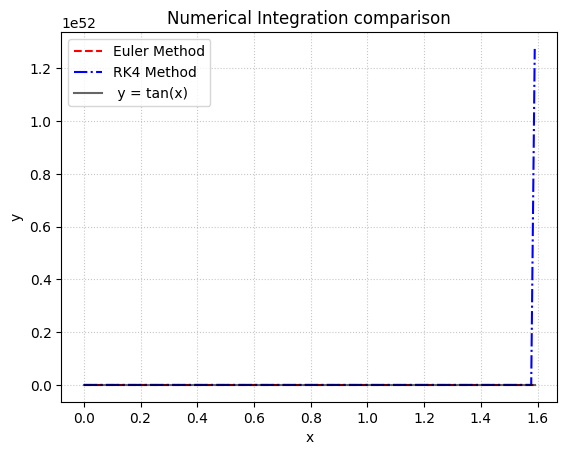

In [3]:
# CSV files 
df_euler = pd.read_csv('euler_output.csv')
df_rk4 = pd.read_csv('rk4_output.csv')

# Comparison with tan(x)
x_exact = np.linspace(0, 1.59, 128)
y_exact = np.tan(x_exact)

plt.plot(df_euler['x'], df_euler['y'], label='Euler Method', color='red', linestyle='--')
plt.plot(df_rk4['x'], df_rk4['y'], label='RK4 Method', color='blue', linestyle='-.')
plt.plot(x_exact, y_exact, label=' y = tan(x)', color='black', alpha=0.6)
plt.title('Numerical Integration comparison')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.savefig(
    'numerical_integration_comparison.pdf', 
    format='pdf', 
    dpi=600,               
    bbox_inches='tight'     
)
plt.show()

In [5]:
df_combined = pd.merge(df_euler, df_rk4, on='x', suffixes=('_Euler', '_RK4'))
df_combined['Exact'] = np.tan(df_combined['x'])
breakdown_region = df_combined[(df_combined['x'] >= 1.50) & (df_combined['x'] <= 1.58)]
print(breakdown_region[['x', 'y_Euler', 'y_RK4', 'Exact']].to_string(index=False, float_format="%.4f"))

     x  y_Euler       y_RK4     Exact
1.5030  10.3641     14.7375   14.7377
1.5155  11.7108     18.0551   18.0558
1.5279  13.4268     23.2906   23.2928
1.5403  15.6787     32.7836   32.7947
1.5527  18.7447     55.2434   55.3578
1.5652  23.1217    167.0140  177.2928
1.5776  29.7750 207727.7250 -147.4540


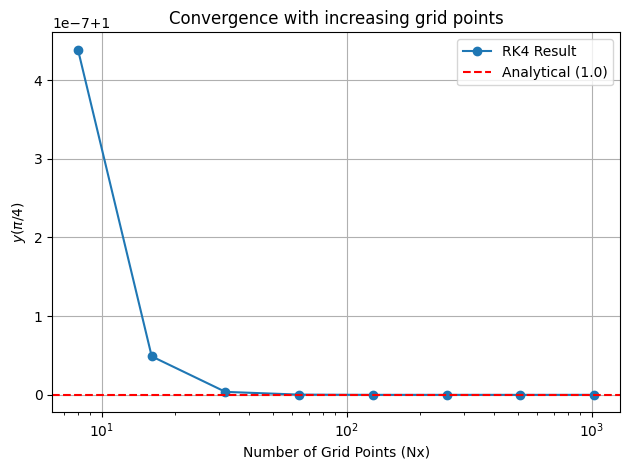

In [ ]:
df_RK4 = pd.read_csv('convergence_data_prob_1.csv')
plt.plot(df_RK4['Nx'], df_RK4['y_final'], 'o-', label='RK4 Result')
plt.axhline(y=1.0, color='r', linestyle='--', label='Analytical (1.0)')
plt.xscale('log')
plt.xlabel('Number of Grid Points (Nx)')
plt.ylabel(r'$y(\pi/4)$')
plt.title('Convergence with increasing grid points')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("RK_4_1c.pdf", dpi=600) 
plt.show()

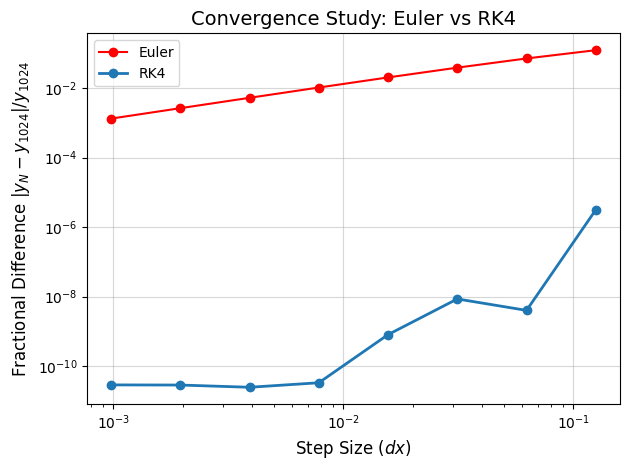

In [63]:
data_cnvrgnce_1 = pd.read_csv('rk4_convergence.csv')
dx = data_cnvrgnce_1['dx'].values
error = data_cnvrgnce_1['frac_diff'].values
mask = error > 0
dx_fit = dx[mask]
error_fit = error[mask]

euler_data = pd.read_csv('euler_convergence.csv')
euler_dx = euler_data['dx']
euler_err = euler_data['frac_diff']
    
plt.loglog(euler_dx, euler_err, 'ro-',label = 'Euler')
plt.loglog(dx, error, 'o-', label=f'RK4', linewidth=2)
plt.title('Convergence Study: Euler vs RK4', fontsize=14)
plt.xlabel('Step Size ($dx$)', fontsize=12)
plt.ylabel('Fractional Difference $|y_N - y_{1024}| / y_{1024}$', fontsize=12)
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("1d.pdf", dpi=600) 
plt.show()

## Problem 2: Maxwell-Boltzmann speed distribution:

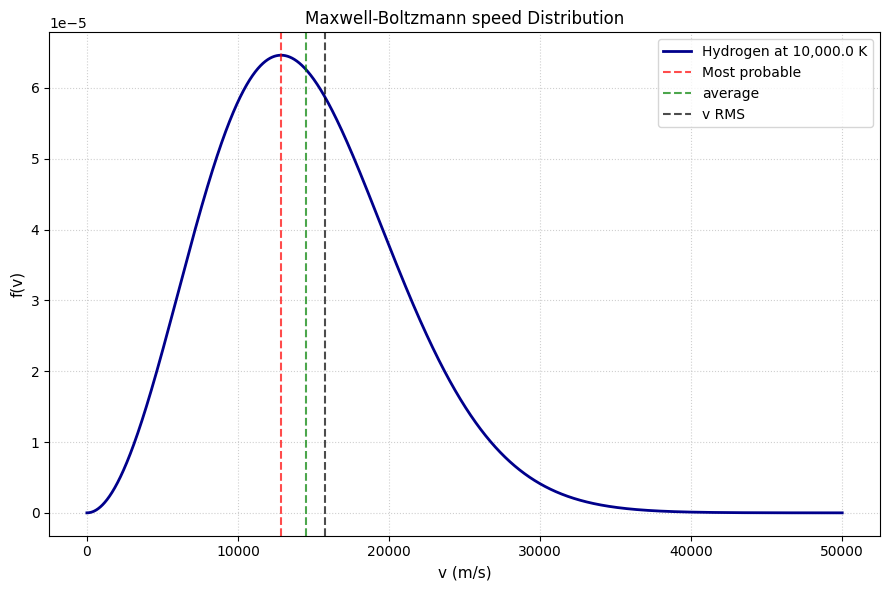

In [6]:
# Constants 
T = 10000.0                # Temperature 
m = 1.6726219e-27          # Mass of Hydrogen atom 
k = 1.380649e-23           # Boltzmann constant 

v = np.arange(0, 50000, 0.1)
f_v =  (m / (2 * np.pi * k * T))**1.5 * (4 * np.pi * v**2) * np.exp(-(m * v**2) / (2 * k * T))

# Most Probable Speed 
v_p = np.sqrt(2 * k * T / m)
v_av = np.sqrt(8 * k * T /(np.pi* m))
v_rms = np.sqrt(3 * k * T /( m))

plt.figure(figsize=(9, 6))
plt.plot(v , f_v, color='darkblue', lw=2, label=f'Hydrogen at {T:,} K')
plt.axvline(v_p , color='red', linestyle='--', alpha=0.7, label=f'Most probable')
plt.axvline(v_av, color = 'green',linestyle='--', alpha=0.7, label=f'average')
plt.axvline(v_rms, color = 'black',linestyle='--', alpha=0.7, label=f'v RMS')
plt.title('Maxwell-Boltzmann speed Distribution', fontsize=12)
plt.xlabel('v (m/s)', fontsize=11)
plt.ylabel('f(v)', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig("Maxwell_Boltzmann_speed.pdf", dpi=600) 
plt.show()

### Convergence test for fractional population which can do the transition from n = 1 to n = 2:

In [32]:
data_step_size = pd.read_csv("MB_convergence_by_steps.csv")
data_v_max = pd.read_csv("MB_convergence_by_vmax.csv")

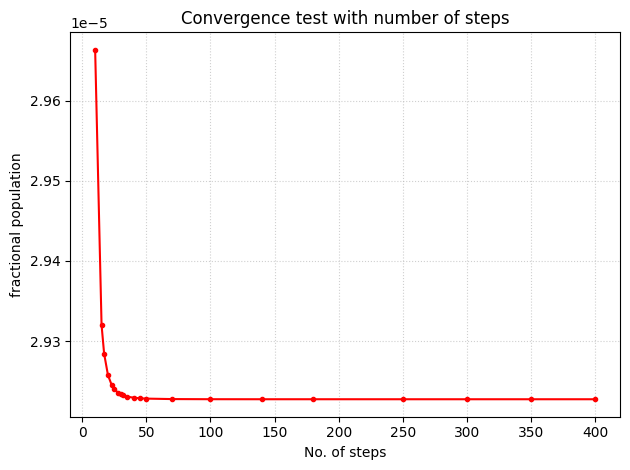

In [41]:

plt.plot(data_step_size['v_steps'], data_step_size['Final_Fraction'], '.-', color = 'red')
plt.title('Convergence test with number of steps', fontsize=12)
plt.ylabel(f'fractional population')
plt.xlabel(f'No. of steps')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig("Convergence_test_with_steps.pdf", dpi=600) 

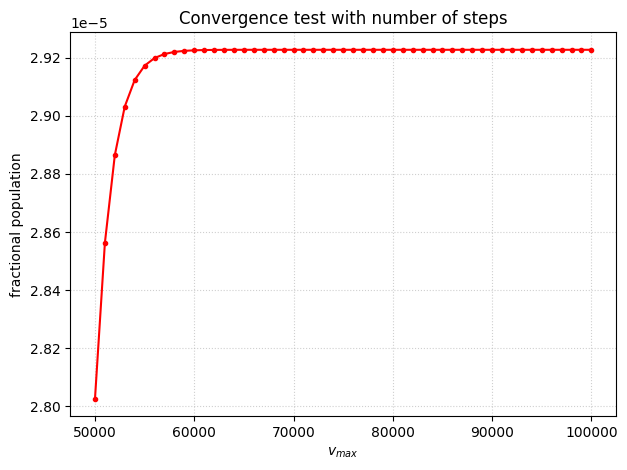

In [42]:
plt.plot(data_v_max['v_max'], data_v_max['Final_Fraction'], '.-',color='red')
plt.title('Convergence test with number of steps', fontsize=12)
plt.ylabel(f'fractional population')
plt.xlabel(r'$v_{max}$')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig("COnvergence_test_with_v_max.pdf", dpi=600) 